In [7]:
import numpy as np


In [8]:
def percentile_inclusive(arr, q):
    return np.percentile(arr, q, method='linear')

In [9]:
def percentile_exclusive(arr, q):
    return np.percentile(arr, q, method='weibull')

In [10]:
test_arr = np.arange(0, 1e6, 1)

print('Inclusive', percentile_inclusive(test_arr, 90))
print('Exclusive', percentile_exclusive(test_arr, 90))



Inclusive 899999.1
Exclusive 899999.9


In [39]:
inclusives = []
exclusives = []
iterations = int(1e4)
for i in range(iterations):
    rand_arr = np.random.normal(0, 5, size=(61,))
    p_inc = percentile_inclusive(rand_arr, 90)
    p_exc = percentile_exclusive(rand_arr, 90)
    inclusives.append(p_inc)
    exclusives.append(p_exc)

In [41]:
import plotly.graph_objects as go
deltas = np.abs(np.array(inclusives) - np.array(exclusives))
fig = go.Figure(
    data=[
        go.Scatter(
            x=list(range(iterations)),
            y=deltas,
            name='delta',
            mode='markers'
        ),
        go.Scatter(
            x=list(range(iterations)),
            y=inclusives,
            name='inclusive',
            mode='markers'
        ),
        go.Scatter(
            x=list(range(iterations)),
            y=exclusives,
            name='exclusive',
            mode='markers'
        )
    ]
)
fig.show()

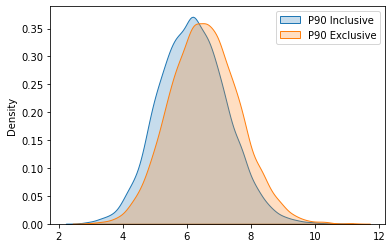

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax = sns.kdeplot(inclusives, shade=True, label='P90 Inclusive', ax=ax)
ax = sns.kdeplot(exclusives, shade=True, label='P90 Exclusive', ax=ax)
ax.legend()

In [14]:
print(np.mean(inclusives) - np.mean(exclusives))

-1.2939199999999857


In [31]:
print(rand_arr)
print(percentile_exclusive(rand_arr, 90))

[2 1 1 1 2 0 2 1 2 0 1 0 2 2 1 0 1 2 1 2 1 1 0 2 0 2 1 0 2 1 0 0 1 0 1 2 0
 1 0 0 2 0 2 2 1 0 2 2 0 1 1 2 1 1 2 0 1 2 0 2 2]
2.0


<AxesSubplot:ylabel='Density'>

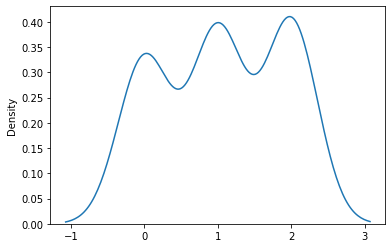

In [32]:
sns.kdeplot(rand_arr)

In [47]:
from scipy import stats
stats.norm.rvs(0, 5, size=61)
stats.rayleigh.rvs(0, 5, size=61)

array([ 1.99366118,  7.44983375,  7.14216987,  6.70448996,  6.81949582,
       11.77812505,  7.77277018,  3.49906689,  6.43522192,  8.91490401,
        1.51758914,  1.57172461,  6.54150425,  7.53688838,  7.34990039,
        4.98072727,  9.20514986,  9.62187887,  0.84436013,  5.19000046,
        7.79201312,  5.89447588,  4.53826283,  4.22182273, 10.03725187,
       10.97564334,  1.76343888,  5.8774607 ,  6.83488138,  8.56701828,
        3.68990718, 11.33491409,  7.08068943,  9.87186815,  3.20060118,
       12.85146208,  5.83870969,  2.37962052,  8.46140142,  2.54785548,
        4.76731193,  4.33705525, 10.35802725,  8.83501012,  7.26972506,
        4.14540712,  6.03677713,  3.8112801 ,  5.53727872,  5.60936746,
        8.30404364,  4.48067644,  2.15448815,  2.96920097,  7.49469018,
        9.93997664,  1.13511066, 13.24794862,  2.36334804,  6.69359214,
        9.80572856])